1199 common trading days

Ticker         USDINR      S&P 500      Nifty 50
Date                                            
2020-01-02  71.025002  3257.850098  12282.200195
2020-01-03  71.415001  3234.850098  12226.650391
2020-01-06  71.731003  3246.280029  11993.049805
2020-01-07  71.787003  3237.179932  12052.950195
2020-01-08  72.160004  3253.050049  12025.349609

----------------------------------------------------
S&P 500            total   80.5%   CAGR  13.2%
Nifty 50           total   92.5%   CAGR  14.8%
Nifty 50 (USD)     total   59.4%   CAGR  10.3%
S&P 500            annualised volatility 21.5%
Nifty 50           annualised volatility 19.4%

Rupee move vs dollar: +20.8% (positive = rupee weaker)
Daily return correlation: 0.35


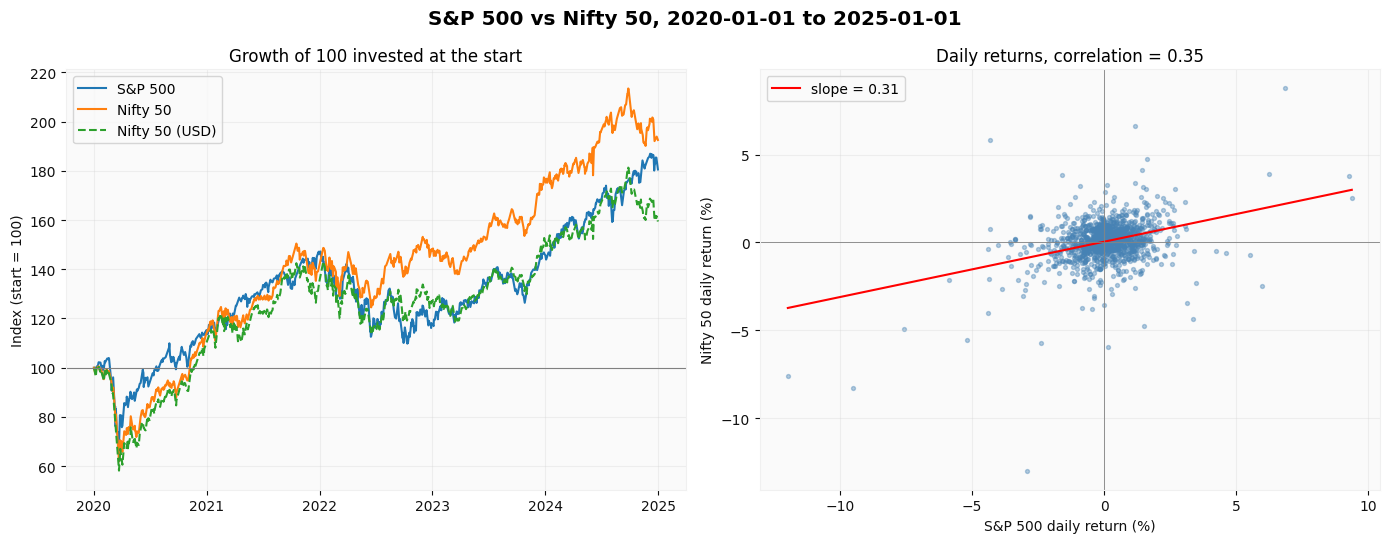

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

START, END = "2020-01-01", "2025-01-01"

TICKERS = {
    "^GSPC": "S&P 500",
    "^NSEI": "Nifty 50",
    "INR=X": "USDINR",
}

raw = yf.download(list(TICKERS), start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
raw = raw.rename(columns=TICKERS)

px = raw.dropna().copy()
print(f"{len(px)} common trading days\n")
print(px.head())

px["Nifty 50 (USD)"] = px["Nifty 50"] / px["USDINR"]

cols = ["S&P 500", "Nifty 50", "Nifty 50 (USD)"]
rebased = px[cols] / px[cols].iloc[0] * 100

ret = px[["S&P 500", "Nifty 50"]].pct_change().dropna()
corr = ret["S&P 500"].corr(ret["Nifty 50"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for col, style in zip(cols, ["-", "-", "--"]):
    axes[0].plot(rebased.index, rebased[col], style, lw=1.5, label=col)
axes[0].axhline(100, color="grey", lw=0.8)
axes[0].set_title("Growth of 100 invested at the start")
axes[0].set_ylabel("Index (start = 100)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(ret["S&P 500"] * 100, ret["Nifty 50"] * 100,
                s=8, alpha=0.4, color="steelblue")
b, a = np.polyfit(ret["S&P 500"], ret["Nifty 50"], 1)
xs = np.linspace(ret["S&P 500"].min(), ret["S&P 500"].max(), 100)
axes[1].plot(xs * 100, (a + b * xs) * 100, "r-", lw=1.5,
             label=f"slope = {b:.2f}")
axes[1].axhline(0, color="grey", lw=0.6)
axes[1].axvline(0, color="grey", lw=0.6)
axes[1].set_title(f"Daily returns, correlation = {corr:.2f}")
axes[1].set_xlabel("S&P 500 daily return (%)")
axes[1].set_ylabel("Nifty 50 daily return (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"S&P 500 vs Nifty 50, {START} to {END}")
fig.tight_layout()

years = len(px) / 252
print("\n" + "-" * 52)
for col in cols:
    total = px[col].iloc[-1] / px[col].iloc[0] - 1 if col in px else \
            rebased[col].iloc[-1] / 100 - 1
    cagr = (1 + total) ** (1 / years) - 1
    print(f"{col:<18} total {total:>7.1%}   CAGR {cagr:>6.1%}")

for col in ["S&P 500", "Nifty 50"]:
    vol = ret[col].std() * np.sqrt(252)
    print(f"{col:<18} annualised volatility {vol:.1%}")

fx = px['USDINR'].iloc[-1] / px['USDINR'].iloc[0] - 1
print(f"\nRupee move vs dollar: {fx:+.1%} (positive = rupee weaker)")
print(f"Daily return correlation: {corr:.2f}")

plt.show()